<a href="https://colab.research.google.com/github/Alexander-Luna/DATA-MINING-I/blob/main/SEMANA%201/eda_adult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos: Dataset Adult Census Income

Integrantes Grupo 3:

*   Kevin Ambuludi Patiño
*   Alexander Luna Arteaga
*   Christian Ruiz Zapata

## Introducción

Este notebook realiza un análisis exploratorio completo del dataset **UCI Adult Census Income**, un dataset clásico en machine learning que contiene información demográfica y laboral de ~48,800 individuos.

### Objetivo
Identificar patrones, relaciones y factores que influyen en si una persona gana más de **$50,000 USD al año** (variable objetivo: `income`).

### Descripción del Dataset
- **Fuente**: UCI Machine Learning Repository
- **Muestras**: 48,842 registros
- **Características**: 14 variables predictoras + 1 variable objetivo

### Variables Principales
- **Numéricas**: age, fnlwgt, educational-num, capital-gain, capital-loss, hours-per-week
- **Categóricas**: workclass, education, marital-status, occupation, relationship, race, gender, native-country
- **Objetivo**: income (≤50K o >50K)



## 2. Carga y Preparación de Datos
Preparar el entorno de trabajo, cargar el dataset *Adult_Census_Income y dejar* los datos listos para el analisis exploratorio.

### 2.1 Importacion de Librerías
Importar las librerias necesarias para manipulacion de datos, calculos numericos y visualizacion grafica.

In [5]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COLUMN = "income"

### 2.2 Carga de Datos
Lectura del archivo `adult.csv`, revisar la dimension del dataset, inspeccionar las primeras filas y confirmar la estructura inicial de columnas.

In [6]:
url = 'https://raw.githubusercontent.com/Alexander-Luna/DATA-MINING-I/b11607cf6feea444285c20c1ef38864ce0fa610e/SEMANA%201/adult-1.csv'
df = pd.read_csv(url)

print(f"\n{'='*80}")
print(f"INFORMACIÓN GENERAL DEL DATASET")
print(f"{'='*80}")
print(f"\nForma: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
display(df.head())


INFORMACIÓN GENERAL DEL DATASET

Forma: 48842 filas × 15 columnas

Primeras filas:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### 2.3 Tipos de Datos
Identificar los tipos de datos de cada variable y resumir cuantas columnas son numericas y categoricas antes de transformar el dataset.

In [7]:
# Información de tipos de datos
print(f"\n{'='*80}")
print(f"TIPOS DE DATOS")
print(f"{'='*80}")
print(f"\n{df.dtypes}")

print(f"\nResumen:")
print(f"  • Numéricas (int64):  {(df.dtypes == 'int64').sum()}")
print(f"  • Numéricas (float64): {(df.dtypes == 'float64').sum()}")
print(f"  • Categóricas (object): {(df.dtypes == 'object').sum()}")


TIPOS DE DATOS

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Resumen:
  • Numéricas (int64):  6
  • Numéricas (float64): 0
  • Categóricas (object): 9


### 2.4 Conversión de Object a String
Convertir columnas de tipo `object` a `string` para estandarizar el tratamiento de variables categoricas.

In [8]:
print('\n' + '='*80)
print('CONVERSIÓN: OBJECT -> STRING')
print('='*80)

object_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nConvirtiendo {len(object_cols)} columnas...\n')

for col in object_cols:
    dtype_before = df[col].dtype
    df[col] = df[col].astype('string')
    dtype_after = df[col].dtype
    unique_count = df[col].nunique()

    print(f'  {col:20} {str(dtype_before):10} -> {str(dtype_after):10} OK ({unique_count} valores)')

print('\nOK: Todas las columnas convertidas exitosamente')


CONVERSIÓN: OBJECT -> STRING

Convirtiendo 9 columnas...

  workclass            object     -> string     OK (9 valores)
  education            object     -> string     OK (16 valores)
  marital-status       object     -> string     OK (7 valores)
  occupation           object     -> string     OK (15 valores)
  relationship         object     -> string     OK (6 valores)
  race                 object     -> string     OK (5 valores)
  gender               object     -> string     OK (2 valores)
  native-country       object     -> string     OK (42 valores)
  income               object     -> string     OK (2 valores)

OK: Todas las columnas convertidas exitosamente


### 2.5 Análisis e Imputación de Valores Faltantes por 'Unknown'
Detectar valores faltantes codificados como `?` y reemplazarlos por `Unknown` en las columnas categoricas afectadas.

In [9]:
# Detectar valores faltantes (representados como '?')
print(f"\n{'='*80}")
print(" VALORES FALTANTES (marcados como '?')")
print(f"{'='*80}")

missing_data = []
for col in df.columns:
    if df[col].dtype == 'string':
        missing_count = (df[col] == '?').sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_data.append({
                'Columna': col,
                'Valores Faltantes': missing_count,
                'Porcentaje': missing_pct,
                'Valores Válidos': len(df) - missing_count
            })
            print(f"\n  {col.upper()}:")
            print(f"    • Faltantes: {missing_count:,} ('{missing_pct:.2f}%')")
            print(f"    • Válidos: {len(df) - missing_count:,} ('{100 - missing_pct:.2f}%')")

if not missing_data:
    print("  Sin valores faltantes")


 VALORES FALTANTES (marcados como '?')

  WORKCLASS:
    • Faltantes: 2,799 ('5.73%')
    • Válidos: 46,043 ('94.27%')

  OCCUPATION:
    • Faltantes: 2,809 ('5.75%')
    • Válidos: 46,033 ('94.25%')

  NATIVE-COUNTRY:
    • Faltantes: 857 ('1.75%')
    • Válidos: 47,985 ('98.25%')


In [10]:
print(f"\n{'='*80}")
print(f"REEMPLAZAR '?' POR 'Unknown'")
print(f"{'='*80}")

# Lista de columnas a procesar
columns_to_clean = ['workclass', 'occupation', 'native-country']

# Reemplazar '?' por 'Unknown'
for col in columns_to_clean:
    missing_count_before = (df[col] == '?').sum()
    df[col] = df[col].replace('?', 'Unknown')
    missing_count_after = (df[col] == '?').sum()

    print(f"\n{col.upper()}:")
    print(f"  Antes: {missing_count_before:,} valores '?'")
    print(f"  Después: {missing_count_after:,} valores '?'")
    print(f"  Reemplazados: {missing_count_before:,}")
    print(f"  ✓ {col} limpiada")


REEMPLAZAR '?' POR 'Unknown'

WORKCLASS:
  Antes: 2,799 valores '?'
  Después: 0 valores '?'
  Reemplazados: 2,799
  ✓ workclass limpiada

OCCUPATION:
  Antes: 2,809 valores '?'
  Después: 0 valores '?'
  Reemplazados: 2,809
  ✓ occupation limpiada

NATIVE-COUNTRY:
  Antes: 857 valores '?'
  Después: 0 valores '?'
  Reemplazados: 857
  ✓ native-country limpiada


### 2.6 Análisis y Eliminación de Registros Duplicados
Cuantificar registros duplicados, crear una copia limpia del dataset y eliminar duplicados exactos para evitar sesgos en conteos y estadisticas.

In [11]:
print(f"\n{'='*80}")
print(f"ANÁLISIS DE REGISTROS DUPLICADOS")
print(f"{'='*80}")

# Duplicados exactos (todas las columnas idénticas)
dup_exact = df.duplicated().sum()
dup_exact_pct = (dup_exact / len(df)) * 100

print(f"\nDuplicados Exactos (todas las columnas idénticas):")
print(f"  • Cantidad: {dup_exact:,} registros ({dup_exact_pct:.4f}%)")
print(f"  • Registros únicos: {len(df) - dup_exact:,}")

if dup_exact > 0:
    print(f"\n✓ Duplicados encontrados. Analizando...")

    # Mostrar algunos duplicados
    dup_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    print(f"\nPrimeros 5 pares de registros duplicados:")
    print(dup_rows.head(10))


ANÁLISIS DE REGISTROS DUPLICADOS

Duplicados Exactos (todas las columnas idénticas):
  • Cantidad: 52 registros (0.1065%)
  • Registros únicos: 48,790

✓ Duplicados encontrados. Analizando...

Primeros 5 pares de registros duplicados:
       age     workclass  fnlwgt     education  educational-num  \
4152    17       Private  153021          12th                8   
40948   17       Private  153021          12th                8   
3900    18  Self-emp-inc  378036          12th                8   
15960   18  Self-emp-inc  378036          12th                8   
33954   19       Private   97261       HS-grad                9   
34979   19       Private   97261       HS-grad                9   
1668    19       Private  130431       5th-6th                3   
19399   19       Private  130431       5th-6th                3   
23271   19       Private  138153  Some-college               10   
37599   19       Private  138153  Some-college               10   

      marital-status      

## 3. Estadísticas Descriptivas
Separar variables numericas y categoricas para calcular resumenes descriptivos adecuados segun el tipo de dato.

In [12]:
# Separar columnas numéricas y categóricas

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [
    column for column in df.select_dtypes(exclude="number").columns.tolist()
]

print("\nVARIABLES IDENTIFICADAS:")
print(f"  Numéricas ({len(num_cols)}): {num_cols}")
print(f"  Categóricas ({len(cat_cols)}): {cat_cols}")


VARIABLES IDENTIFICADAS:
  Numéricas (6): ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
  Categóricas (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


### 3.1 Estadísticas Descripcticas (Númericas)
Calcular medidas descriptivas de variables numericas, como conteo, media, desviacion estandar, minimos, maximos y cuartiles.

In [13]:
print("\n=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===")
print(df[num_cols].describe().round(2))


=== ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS ===
            age      fnlwgt  educational-num  capital-gain  capital-loss  \
count  48842.00    48842.00         48842.00      48842.00       48842.0   
mean      38.64   189664.13            10.08       1079.07          87.5   
std       13.71   105604.03             2.57       7452.02         403.0   
min       17.00    12285.00             1.00          0.00           0.0   
25%       28.00   117550.50             9.00          0.00           0.0   
50%       37.00   178144.50            10.00          0.00           0.0   
75%       48.00   237642.00            12.00          0.00           0.0   
max       90.00  1490400.00            16.00      99999.00        4356.0   

       hours-per-week  
count        48842.00  
mean            40.42  
std             12.39  
min              1.00  
25%             40.00  
50%             40.00  
75%             45.00  
max             99.00  


### 3.2 Estadísticas Descripcticas (Categóricas)
Revisar frecuencias, categorias principales y distribucion de valores para las variables categoricas relevantes.

In [14]:
print(f"\n{'='*80}")
print(f"ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print(f"{'='*80}")

for col in ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']:
    print(f"\n\n{col.upper()}:")
    print(f"{'─'*60}")

    value_counts = df[col].value_counts()
    value_pcts = (value_counts / len(df) * 100)

    print(f"\nTotal de categorías: {value_counts.nunique()}")
    print(f"\nCategorías:")
    for i, (cat, count) in enumerate(value_counts.items(), 1):
        pct = value_pcts[cat] # type: ignore
        print(f"  {i}. {cat}: {count:,} ({pct:.2f}%)")

    if 'Unknown' in value_counts.index:
        missing_count = value_counts['Unknown']
        missing_pct = value_pcts['Unknown']
        print(f"\n  Unknown (Missing): {missing_count:,} ({missing_pct:.2f}%)")


ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS


WORKCLASS:
────────────────────────────────────────────────────────────

Total de categorías: 9

Categorías:
  1. Private: 33,906 (69.42%)
  2. Self-emp-not-inc: 3,862 (7.91%)
  3. Local-gov: 3,136 (6.42%)
  4. Unknown: 2,799 (5.73%)
  5. State-gov: 1,981 (4.06%)
  6. Self-emp-inc: 1,695 (3.47%)
  7. Federal-gov: 1,432 (2.93%)
  8. Without-pay: 21 (0.04%)
  9. Never-worked: 10 (0.02%)

  Unknown (Missing): 2,799 (5.73%)


EDUCATION:
────────────────────────────────────────────────────────────

Total de categorías: 16

Categorías:
  1. HS-grad: 15,784 (32.32%)
  2. Some-college: 10,878 (22.27%)
  3. Bachelors: 8,025 (16.43%)
  4. Masters: 2,657 (5.44%)
  5. Assoc-voc: 2,061 (4.22%)
  6. 11th: 1,812 (3.71%)
  7. Assoc-acdm: 1,601 (3.28%)
  8. 10th: 1,389 (2.84%)
  9. 7th-8th: 955 (1.96%)
  10. Prof-school: 834 (1.71%)
  11. 9th: 756 (1.55%)
  12. 12th: 657 (1.35%)
  13. Doctorate: 594 (1.22%)
  14. 5th-6th: 509 (1.04%)
  15. 1st-4th: 2

## 4. Distribuciones Univariadas
Analizar cada variable de forma individual para entender su forma, frecuencia, dispersion y posibles valores atipicos.

### 4.1. Funciones de apoyo visual
Definir configuraciones y funciones auxiliares para mantener un estilo consistente en titulos, ejes, grillas y etiquetas de las graficas.

In [15]:
# Configuración de estilo
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Función auxiliar para estilizar ejes
def style_ax(ax, title='', xlabel='', ylabel=''):
    """Aplica estilo con texto en negrita a un eje."""
    if title:
        ax.set_title(title, fontweight='bold', fontsize=11)
    if xlabel:
        ax.set_xlabel(xlabel, fontweight='bold', fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

def hide_unused_axes(axes, used_count):
    for ax in axes[used_count:]:
        ax.set_visible(False)


def subplot_grid(n_items, n_cols=3, width=6, height=4.3):
    n_rows = math.ceil(n_items / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(width * n_cols, height * n_rows))
    axes = np.array(axes).reshape(-1)
    return fig, axes


def prepare_top_categories(series, top_n=10):
    counts = series.value_counts(dropna=False)
    if len(counts) <= top_n:
        return series.astype(str), counts.index.astype(str).tolist(), False
    top_values = counts.head(top_n).index
    grouped = series.where(series.isin(top_values), other="Otros").astype(str)
    order = grouped.value_counts().index.tolist()
    return grouped, order, True

### 4.2 Representación gráfica de Distribuciones Númericas
Generar histogramas en subplots para observar la distribucion, asimetria y concentracion de cada variable numerica.

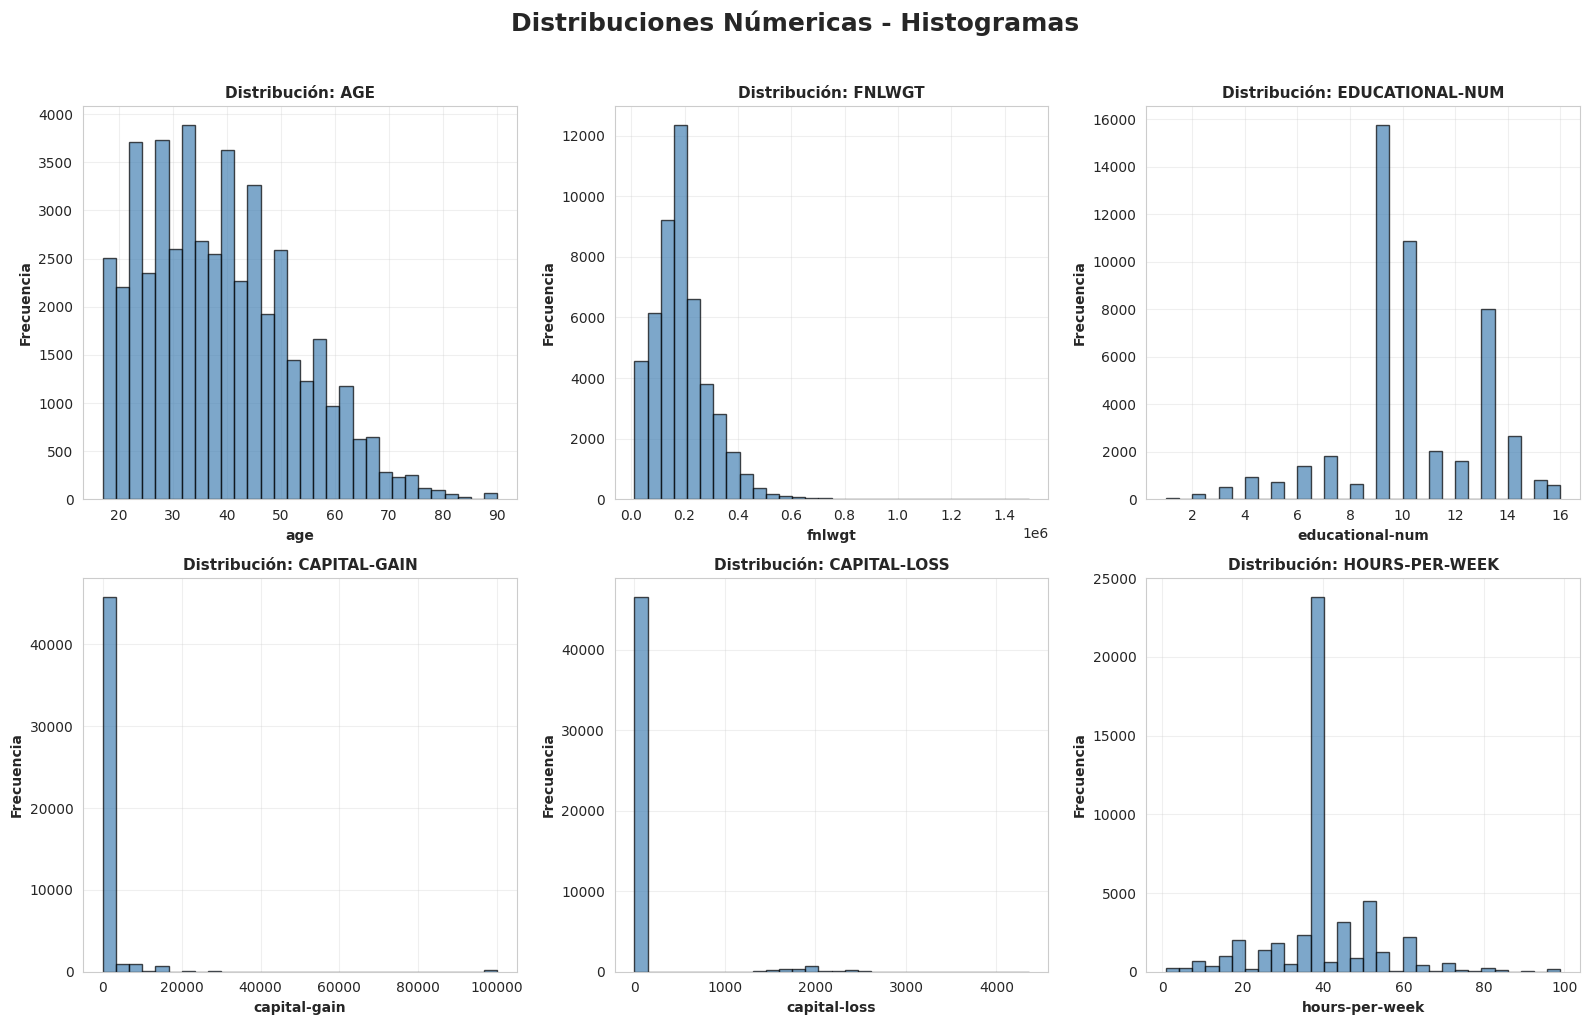

In [16]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    style_ax(ax, title=f'Distribución: {col.upper()}', xlabel=col, ylabel='Frecuencia')

fig.suptitle("Distribuciones Númericas - Histogramas", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


### 4.3  Representación gráfica de Boxplots de Outliers
Crear boxplots en subplots para detectar dispersion, mediana y posibles outliers en las variables numericas.

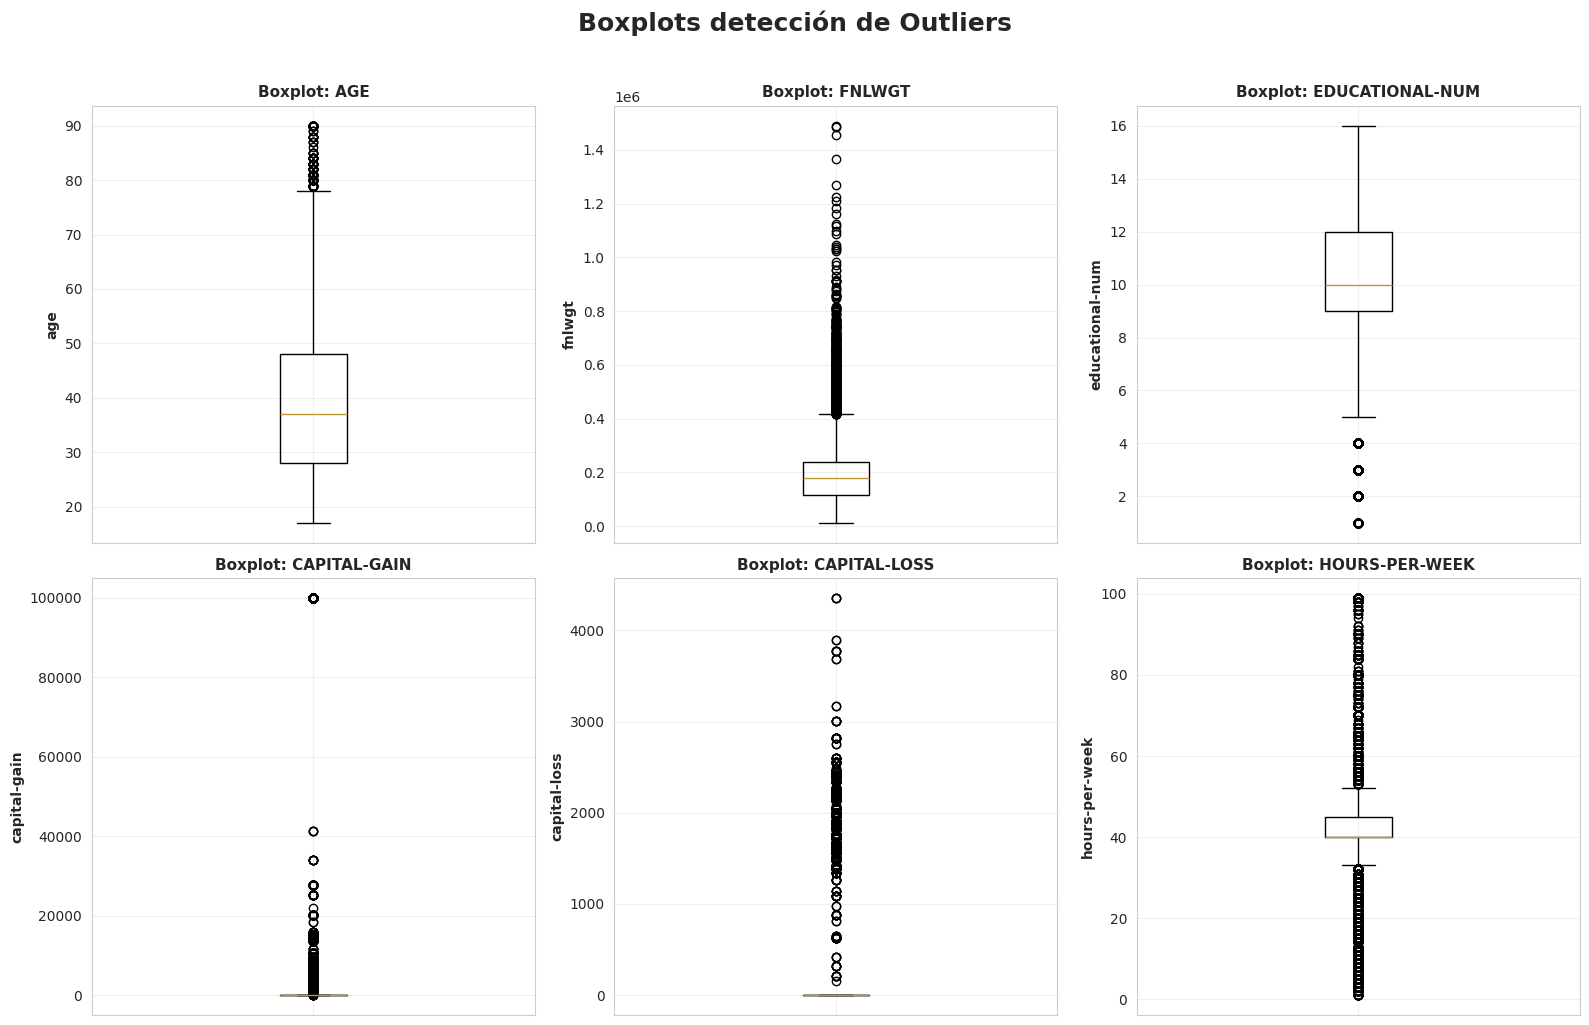


 Boxplots generados - Análisis de outliers:
  age: 216 outliers (0.44%)
  fnlwgt: 1453 outliers (2.97%)
  educational-num: 1794 outliers (3.67%)
  capital-gain: 4035 outliers (8.26%)
  capital-loss: 2282 outliers (4.67%)
  hours-per-week: 13496 outliers (27.63%)


In [17]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    ax.boxplot(df[col].dropna(), vert=True)
    style_ax(ax, title=f'Boxplot: {col.upper()}', xlabel='', ylabel=col)
    ax.set_xticklabels([])

fig.suptitle("Boxplots detección de Outliers", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\n Boxplots generados - Análisis de outliers:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

### 4.4 Representación gráfica de Countsplot de Variables Categóricas
Visualizar frecuencias de variables categoricas clave mediante countplots organizados en subplots.

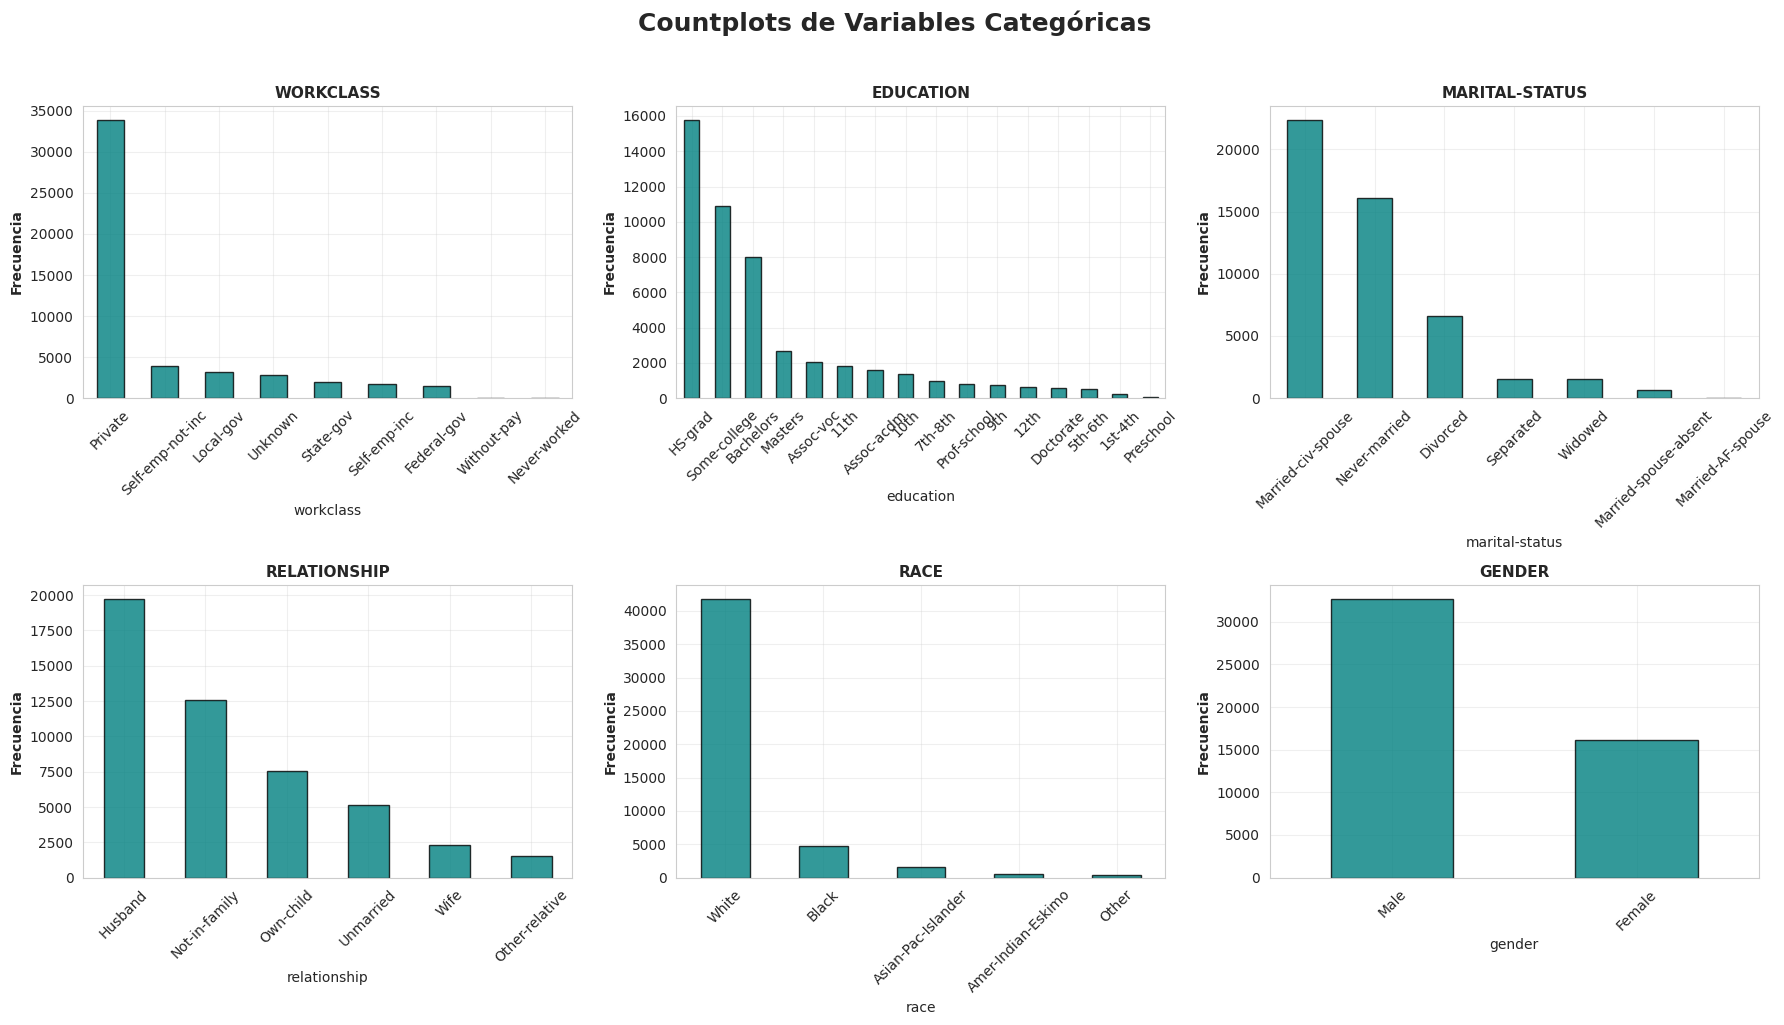

In [18]:
# Countplots de variables categóricas clave
key_cat = ['workclass', 'education', 'marital-status','relationship', 'race', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(key_cat):
    ax = axes[idx]
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', ax=ax, color='teal', alpha=0.8, edgecolor='black')
    style_ax(ax, title=f'{col.upper()}', xlabel='', ylabel='Frecuencia')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Countplots de Variables Categóricas", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Representación gráfica de Countsplot de Paises de Origen
Mostrar los paises de origen mas frecuentes para facilitar la lectura de una variable categorica con muchas categorias.

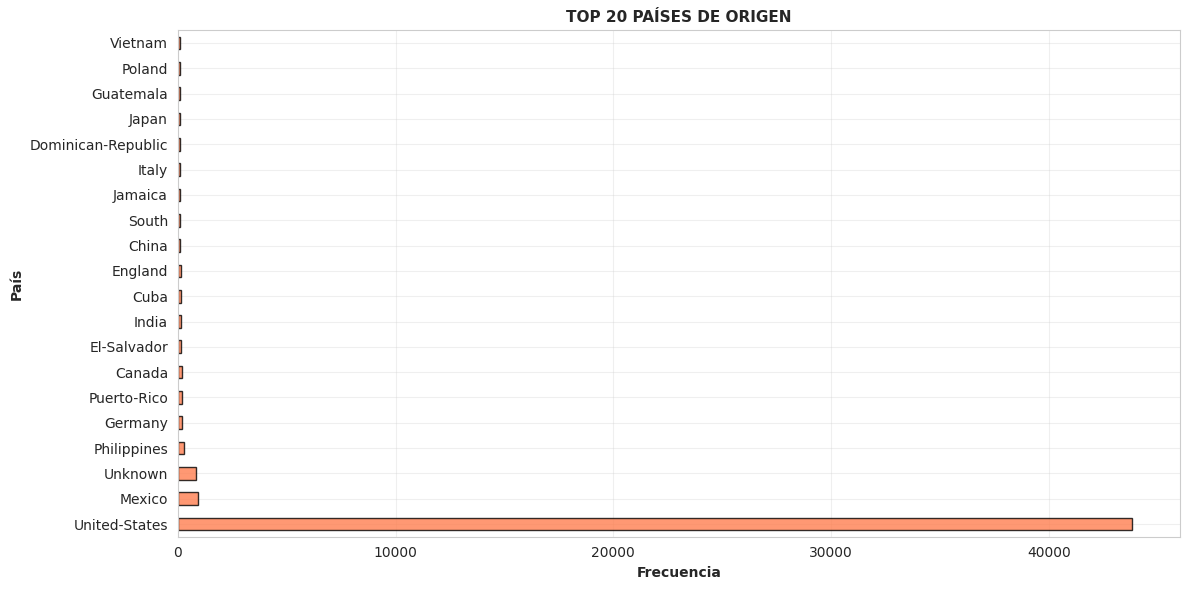

In [19]:
# Native-country
fig, ax = plt.subplots(figsize=(12, 6))
top_countries = df['native-country'].value_counts().head(20)
top_countries.plot(kind='barh', ax=ax, color='coral', alpha=0.8, edgecolor='black')
style_ax(ax, title='TOP 20 PAÍSES DE ORIGEN', xlabel='Frecuencia', ylabel='País')
plt.tight_layout()
plt.show()

### 4.6 Representación gráfica de Countsplot de Occupation
Graficar la frecuencia de ocupaciones para identificar cuales categorias tienen mayor representacion en el dataset.

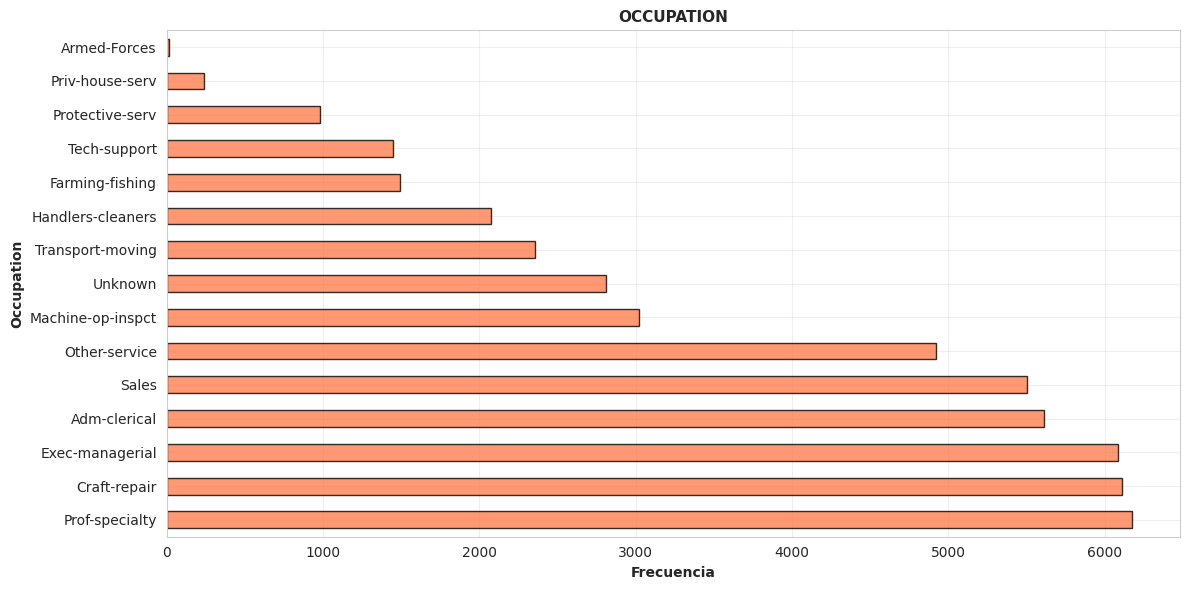

In [20]:
# Native-country
fig, ax = plt.subplots(figsize=(12, 6))
top_countries = df['occupation'].value_counts()
top_countries.plot(kind='barh', ax=ax, color='coral', alpha=0.8, edgecolor='black')
style_ax(ax, title='OCCUPATION', xlabel='Frecuencia', ylabel='Occupation')
plt.tight_layout()
plt.show()

### 4.7 Análisis Univariado: Todas las Variables Categóricas
Visualización completa de la frecuencia de las variables categóricas utilizando las funciones de apoyo definidas anteriormente.

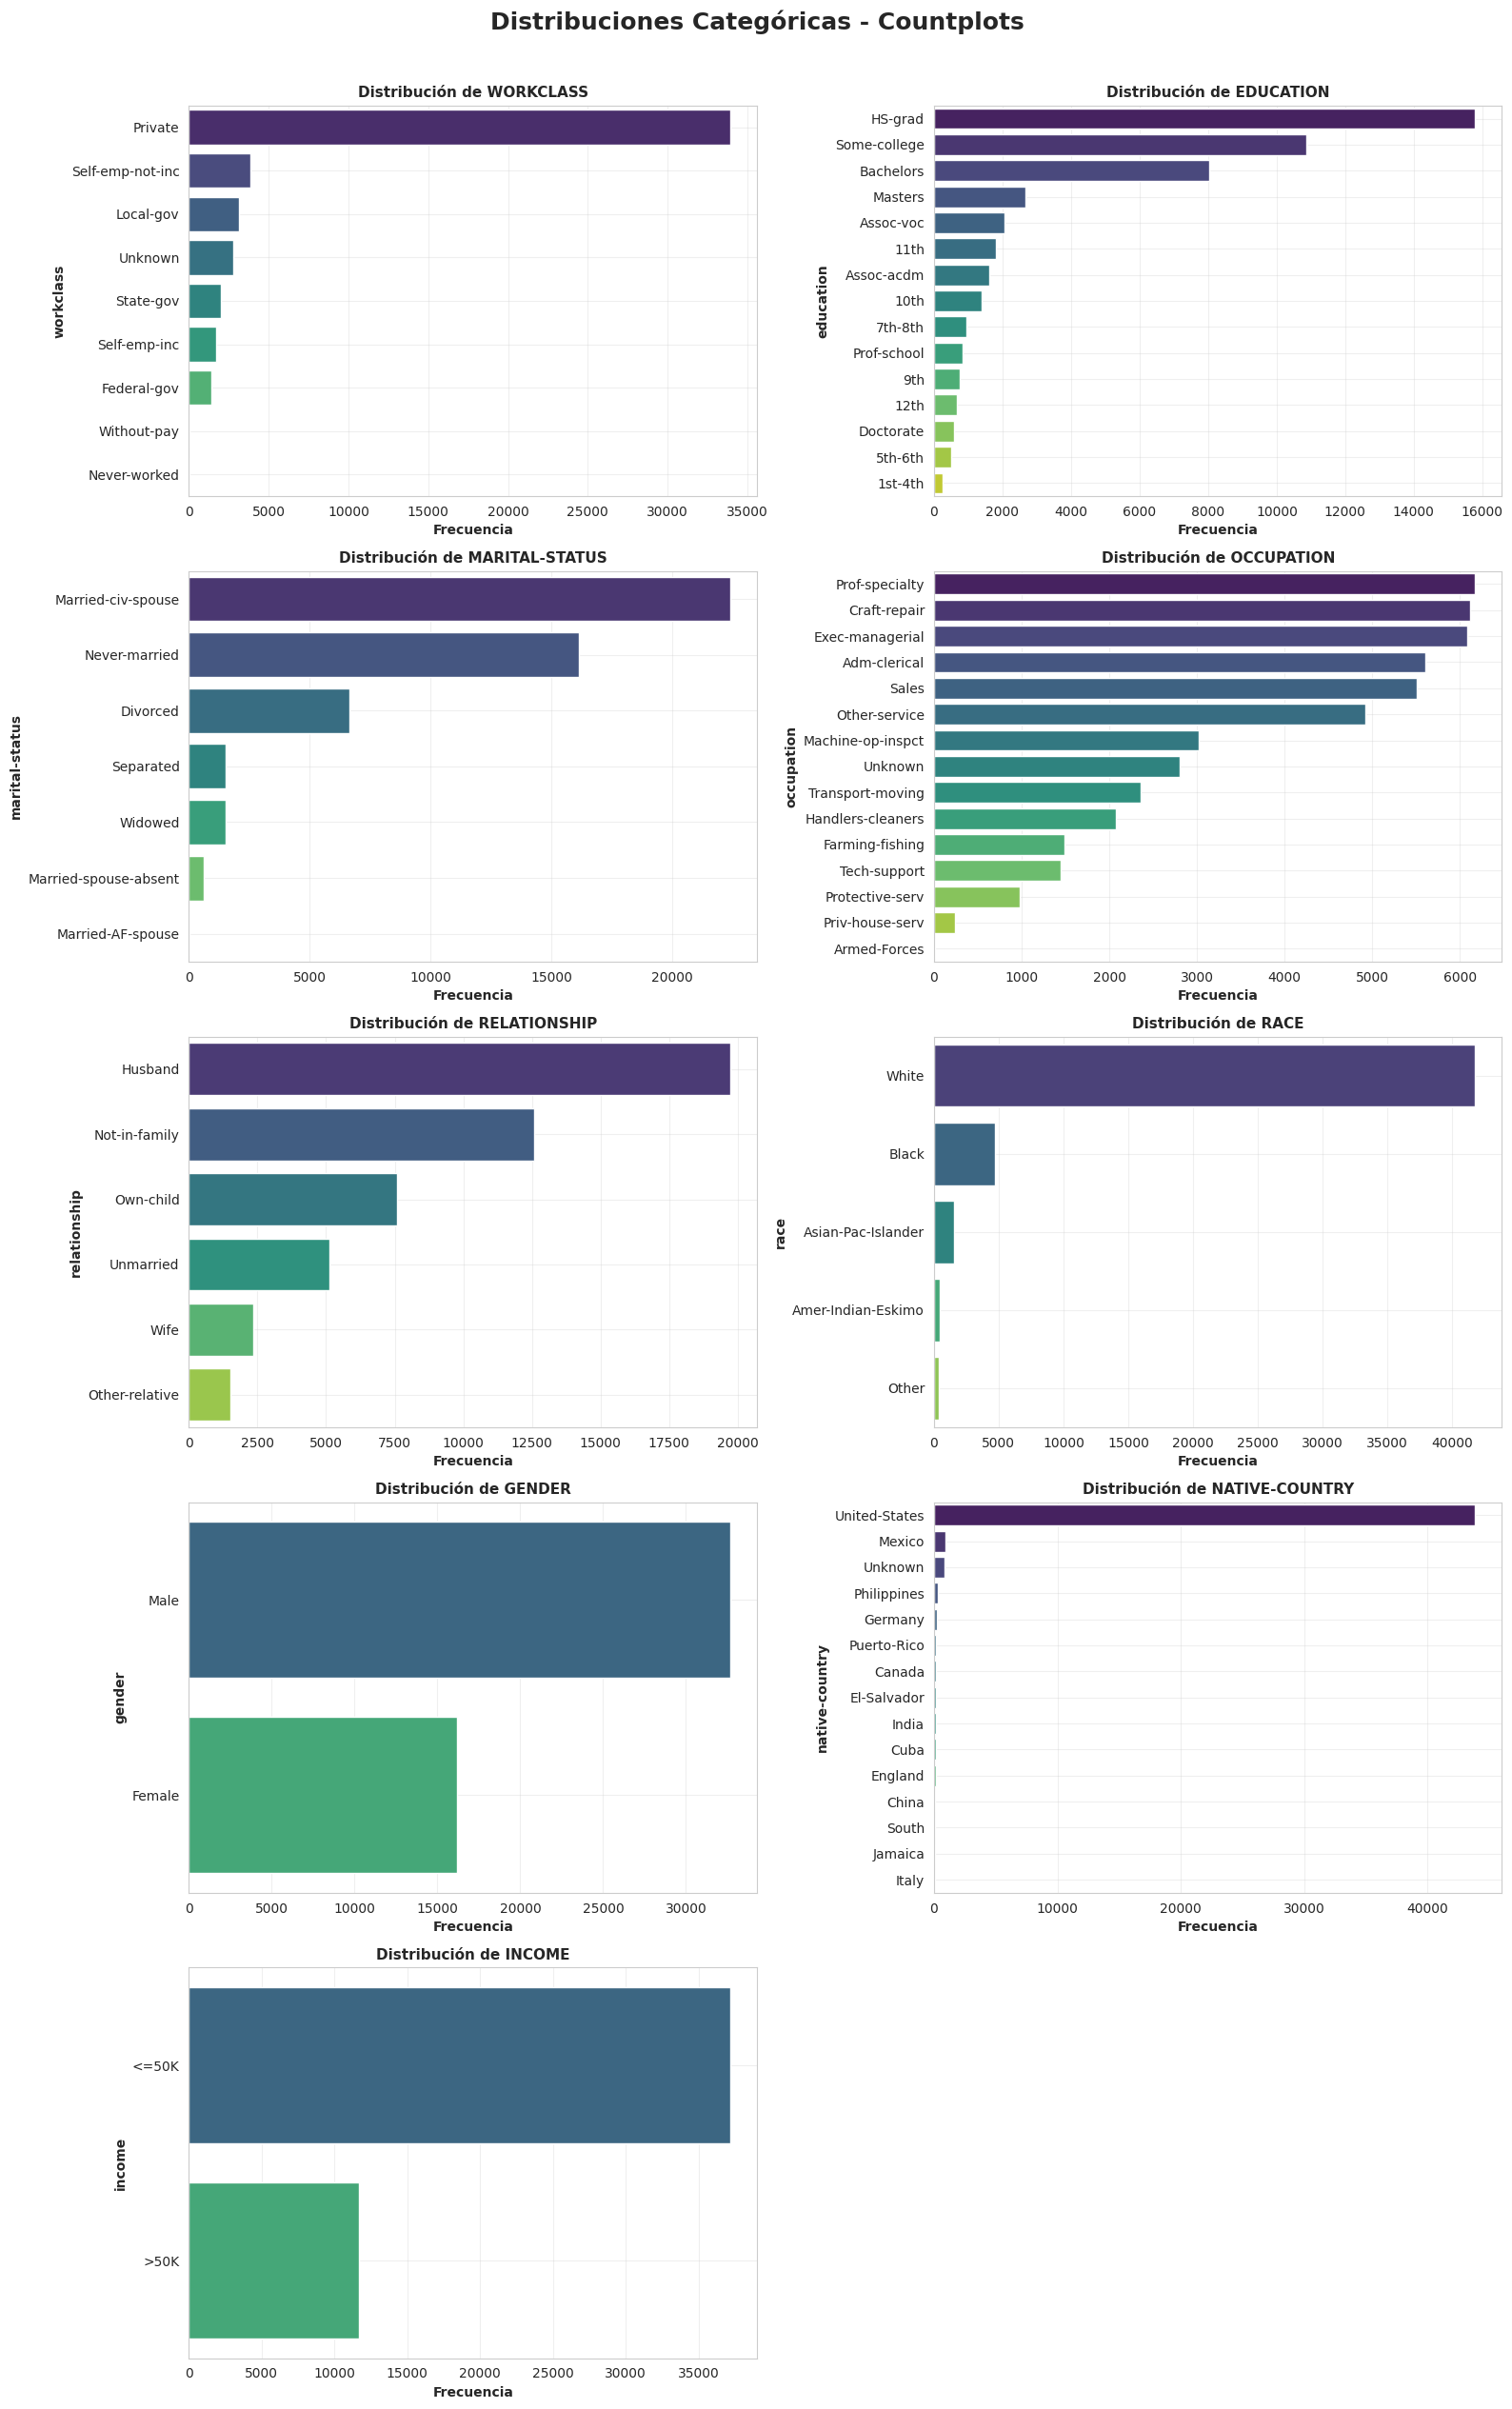

In [21]:
# Generar countplots para todas las variables categóricas
fig, axes = subplot_grid(len(cat_cols), n_cols=2, width=8, height=5)

for ax, col in zip(axes, cat_cols):
    # Obtener frecuencias y ordenar
    value_counts = df[col].value_counts().head(15) # Limitamos a 15 para legibilidad

    sns.barplot(
        x=value_counts.values,
        y=value_counts.index.astype(str),
        ax=ax,
        palette='viridis',
        hue=value_counts.index.astype(str),
        legend=False
    )

    style_ax(
        ax,
        title=f'Distribución de {col.upper()}',
        xlabel='Frecuencia',
        ylabel=col
    )

hide_unused_axes(axes, len(cat_cols))
fig.suptitle("Distribuciones Categóricas - Countplots", fontweight="bold", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 5. Análisis Bivariado
Evaluar relaciones entre variables explicativas y la variable objetivo `income` mediante graficas comparativas.

### 5.1 Análisis Bivariado: Variables Numéricas vs Income
Utilizamos boxplots para comparar las distribuciones de variables continuas entre los dos grupos de ingresos.

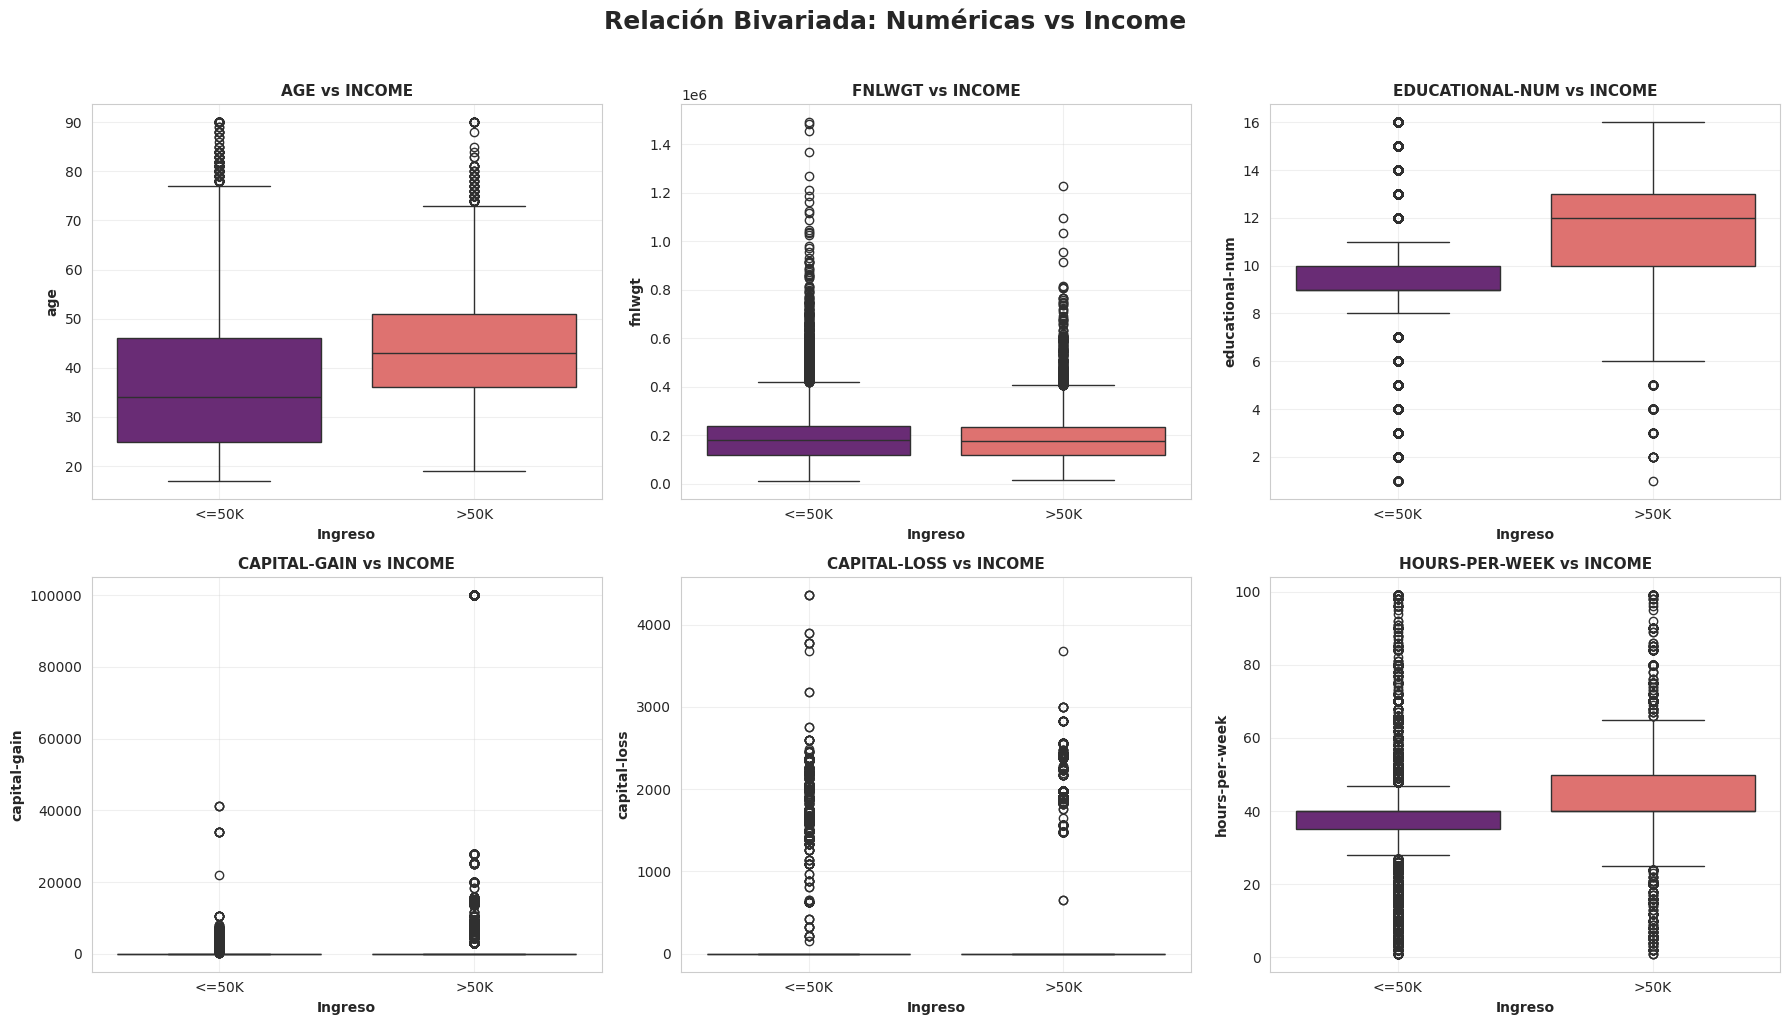

In [28]:
fig, axes = subplot_grid(len(num_cols), n_cols=3, width=6, height=5)

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=ax, palette='magma', hue=TARGET_COLUMN, legend=False)
    style_ax(ax, title=f'{col.upper()} vs {TARGET_COLUMN.upper()}', xlabel='Ingreso', ylabel=col)

hide_unused_axes(axes, len(num_cols))
fig.suptitle("Relación Bivariada: Numéricas vs Income", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Análisis Bivariado: Variables Categóricas vs Income
Visualizamos la relación entre las categorías y el nivel de ingresos mediante gráficos de barras apilados o agrupados.

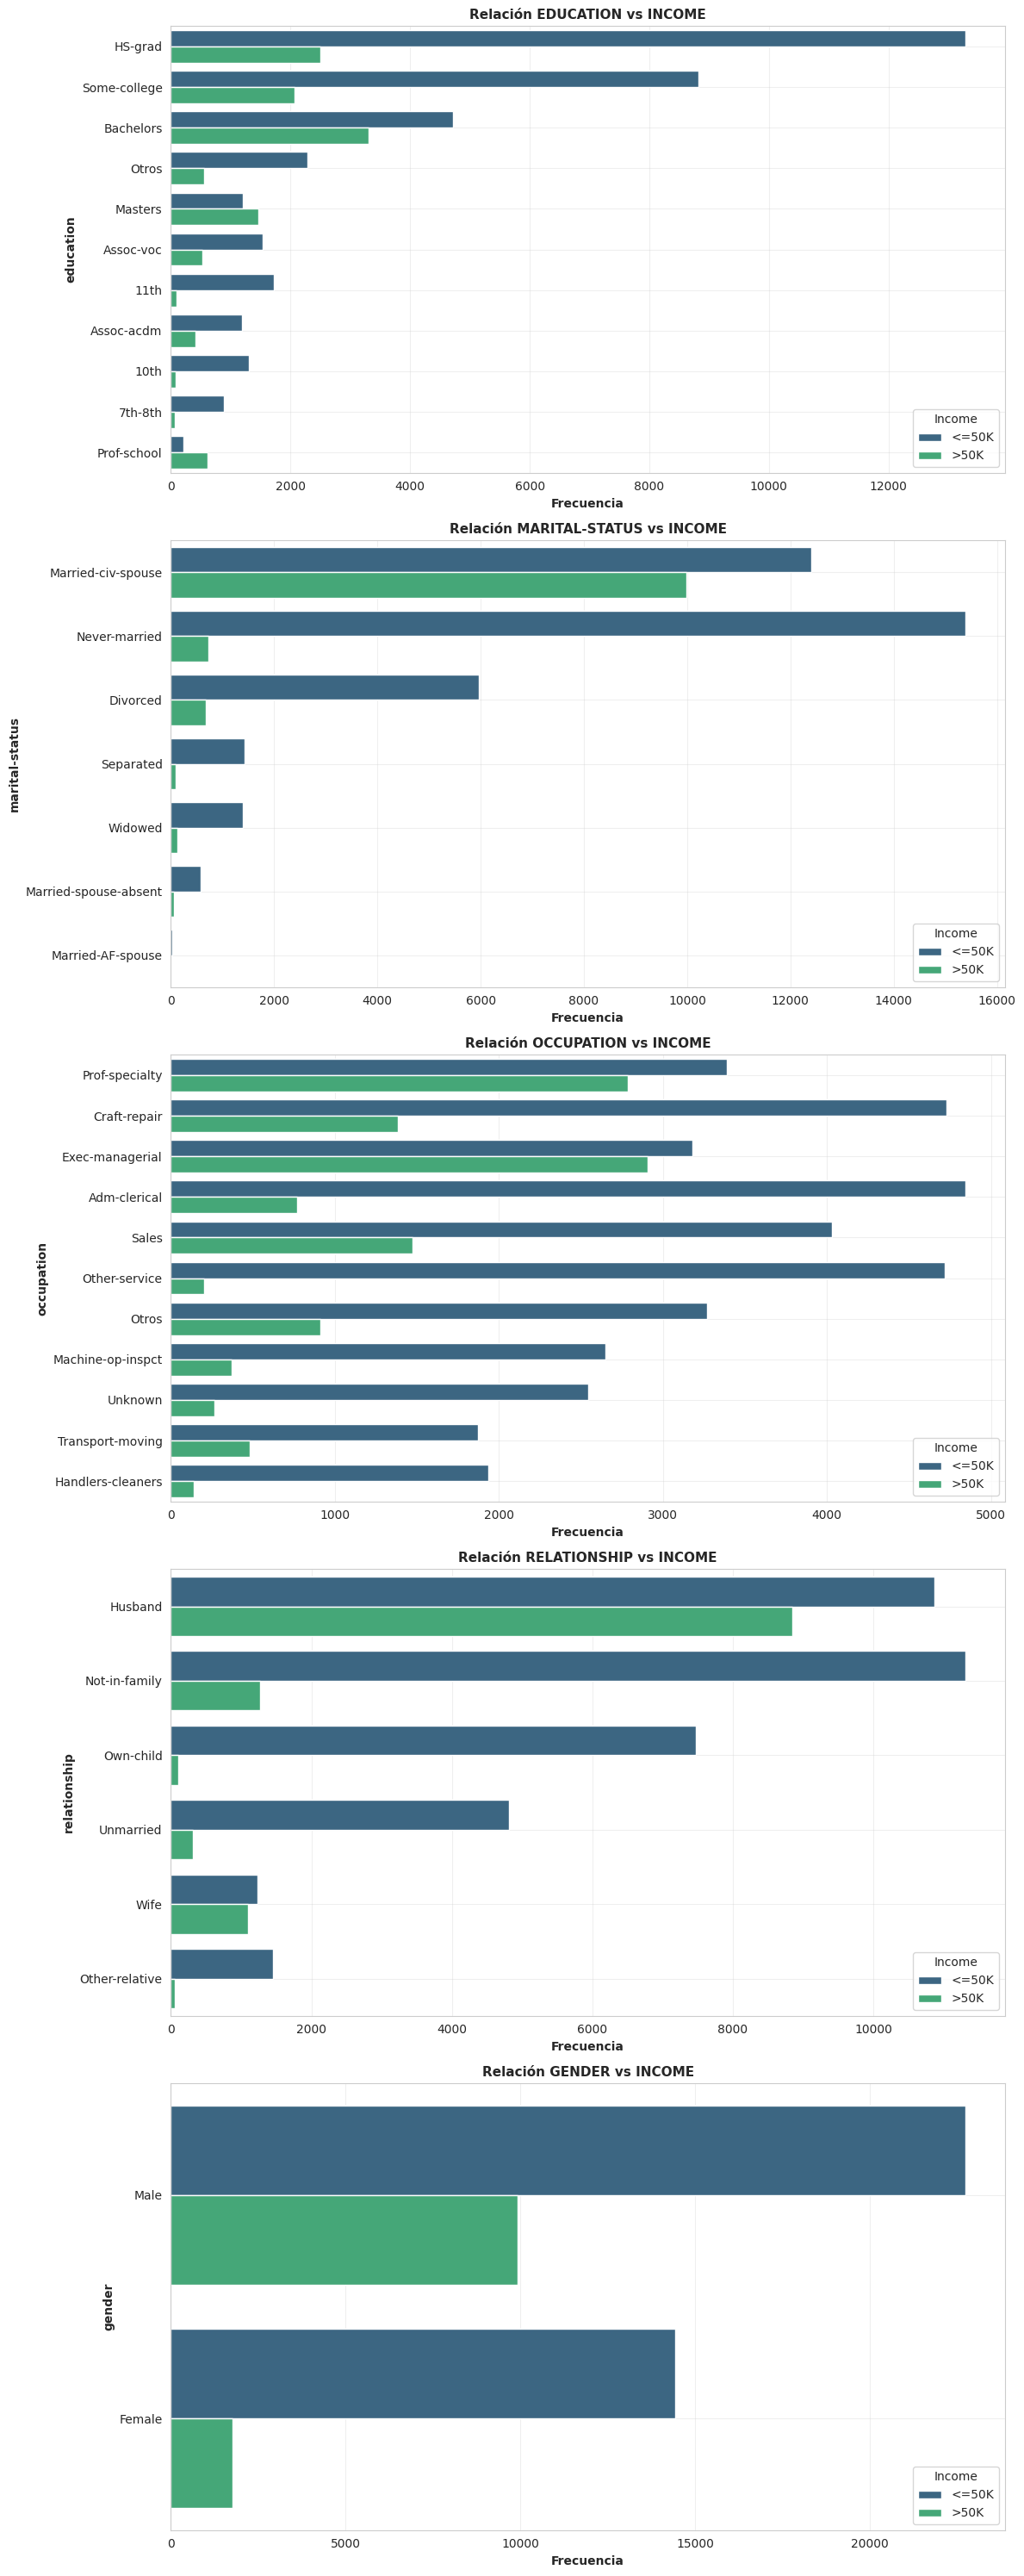

In [29]:
# Seleccionamos las variables categóricas más relevantes para el cruce
selected_cats = ['education', 'marital-status', 'occupation', 'relationship', 'gender']

fig, axes = subplot_grid(len(selected_cats), n_cols=1, width=12, height=6)

for ax, col in zip(axes, selected_cats):
    # Preparamos las top categorías para evitar saturar el gráfico
    plot_series, order, _ = prepare_top_categories(df[col], top_n=10)
    temp_df = df.copy()
    temp_df[col] = plot_series

    # Calcular porcentajes para mejor interpretación
    sns.countplot(data=temp_df, y=col, hue=TARGET_COLUMN, order=order, ax=ax, palette='viridis')
    style_ax(ax, title=f'Relación {col.upper()} vs INCOME', xlabel='Frecuencia', ylabel=col)
    ax.legend(title='Income', loc='lower right')

hide_unused_axes(axes, len(selected_cats))
plt.tight_layout()
plt.show()

### 5.1 Boxplots: Variables Numericas vs Income
Comparar la distribucion de cada variable numerica entre los grupos de ingreso `<=50K` y `>50K` usando boxplots.

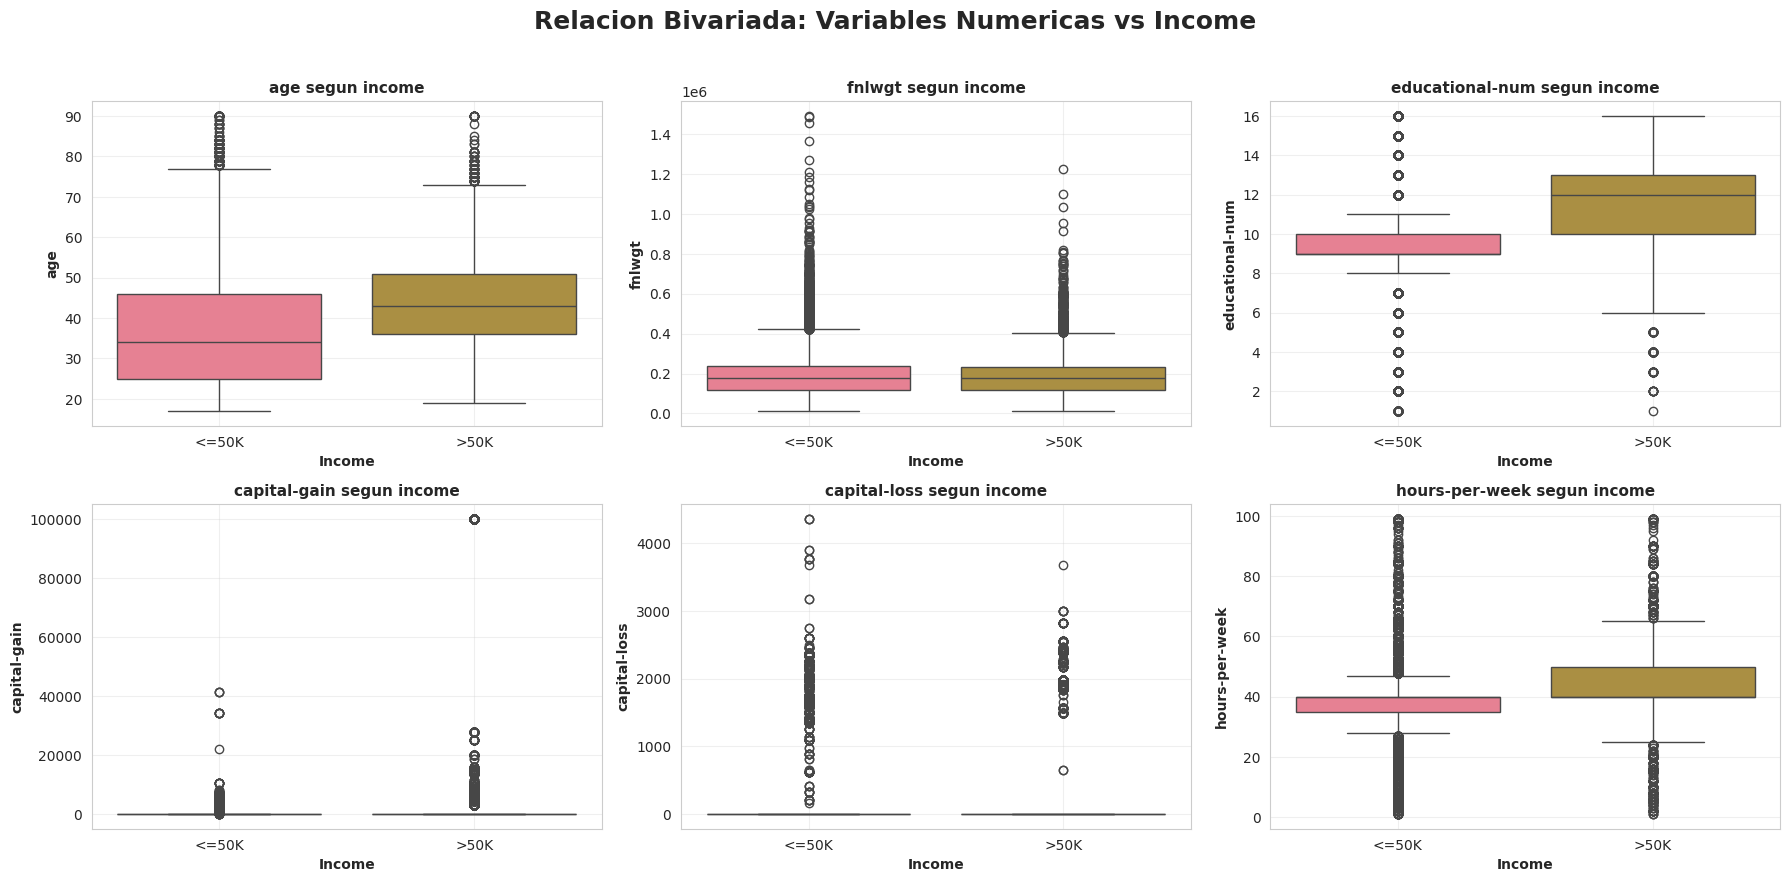

In [22]:
fig, axes = subplot_grid(len(num_cols), n_cols=3)

for ax, column in zip(axes, num_cols):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column, ax=ax, hue=TARGET_COLUMN, legend=False)
    style_ax(
        ax,
        title=f"{column} segun income",
        xlabel="Income",
        ylabel=column,
    )

hide_unused_axes(axes, len(num_cols))
fig.suptitle("Relacion Bivariada: Variables Numericas vs Income", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Histogramas: Distribuciones Numericas por Income
Superponer histogramas por clase de ingreso para identificar diferencias en la forma de las distribuciones numericas.

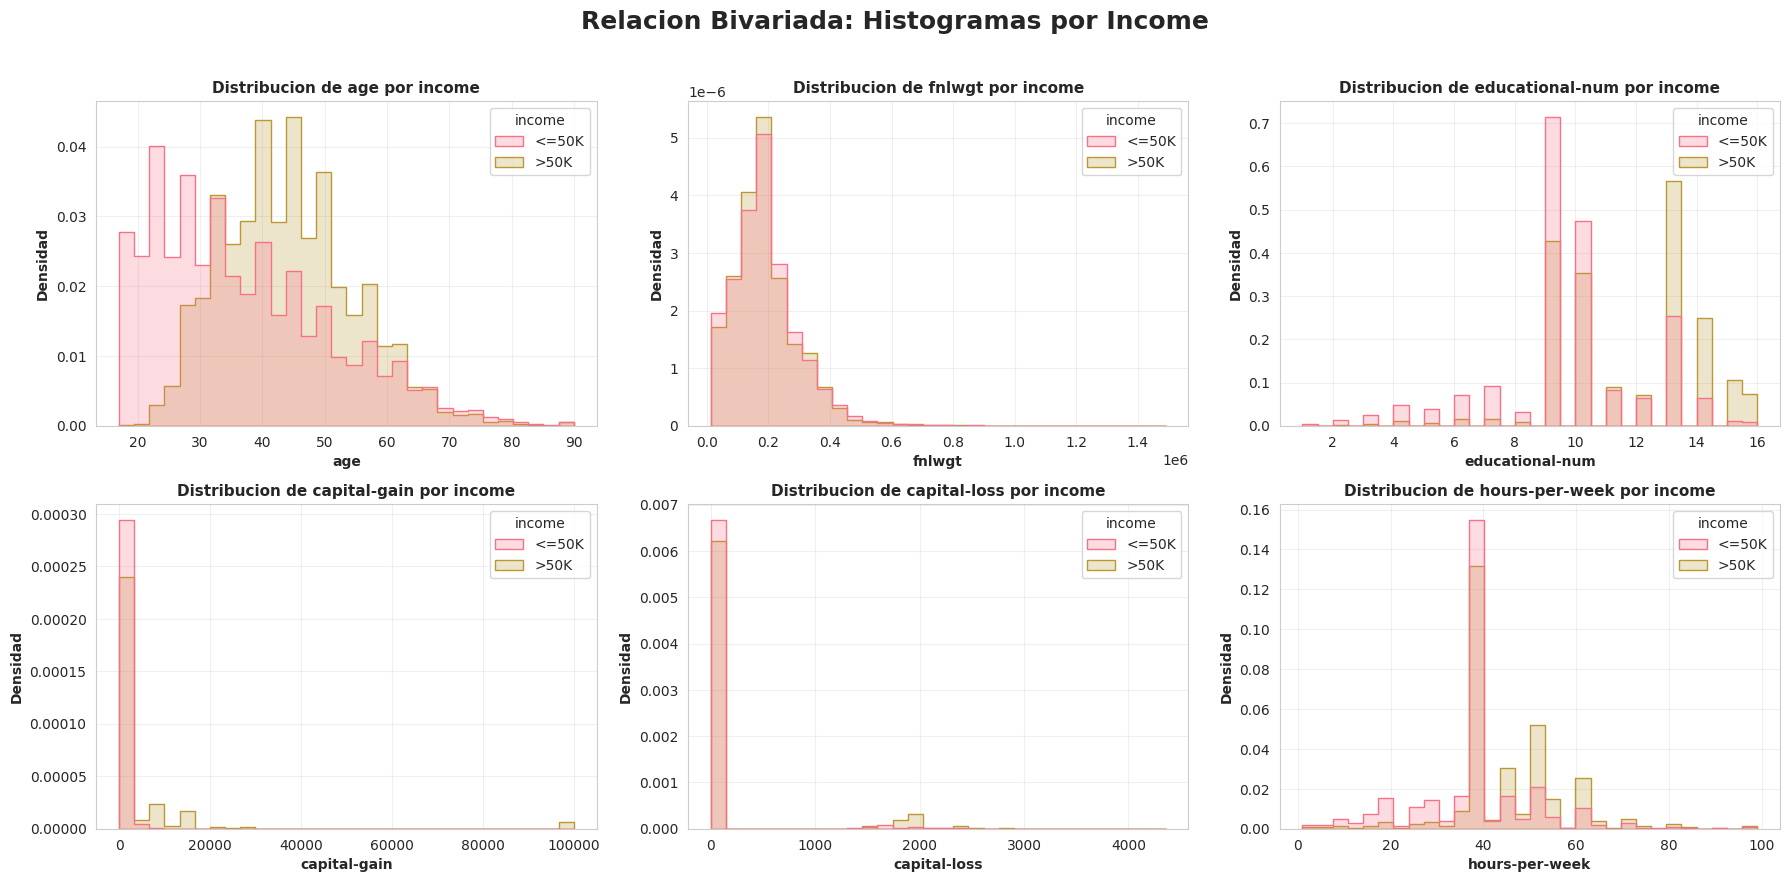

In [23]:
fig, axes = subplot_grid(len(num_cols), n_cols=3)

for ax, column in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=column,
        hue=TARGET_COLUMN,
        bins=30,
        kde=False,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    style_ax(
        ax,
        title=f"Distribucion de {column} por income",
        xlabel=column,
        ylabel="Densidad",
    )

hide_unused_axes(axes, len(num_cols))
fig.suptitle("Relacion Bivariada: Histogramas por Income", fontweight="bold", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 5.3. Countplots: Variables Categoricas vs Income
Comparar frecuencias de categorias segun `income`, agrupando categorias extensas para mantener graficas legibles.

/tmp/ipykernel_750/2467056972.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Income", title_fontproperties={"weight": "bold"})


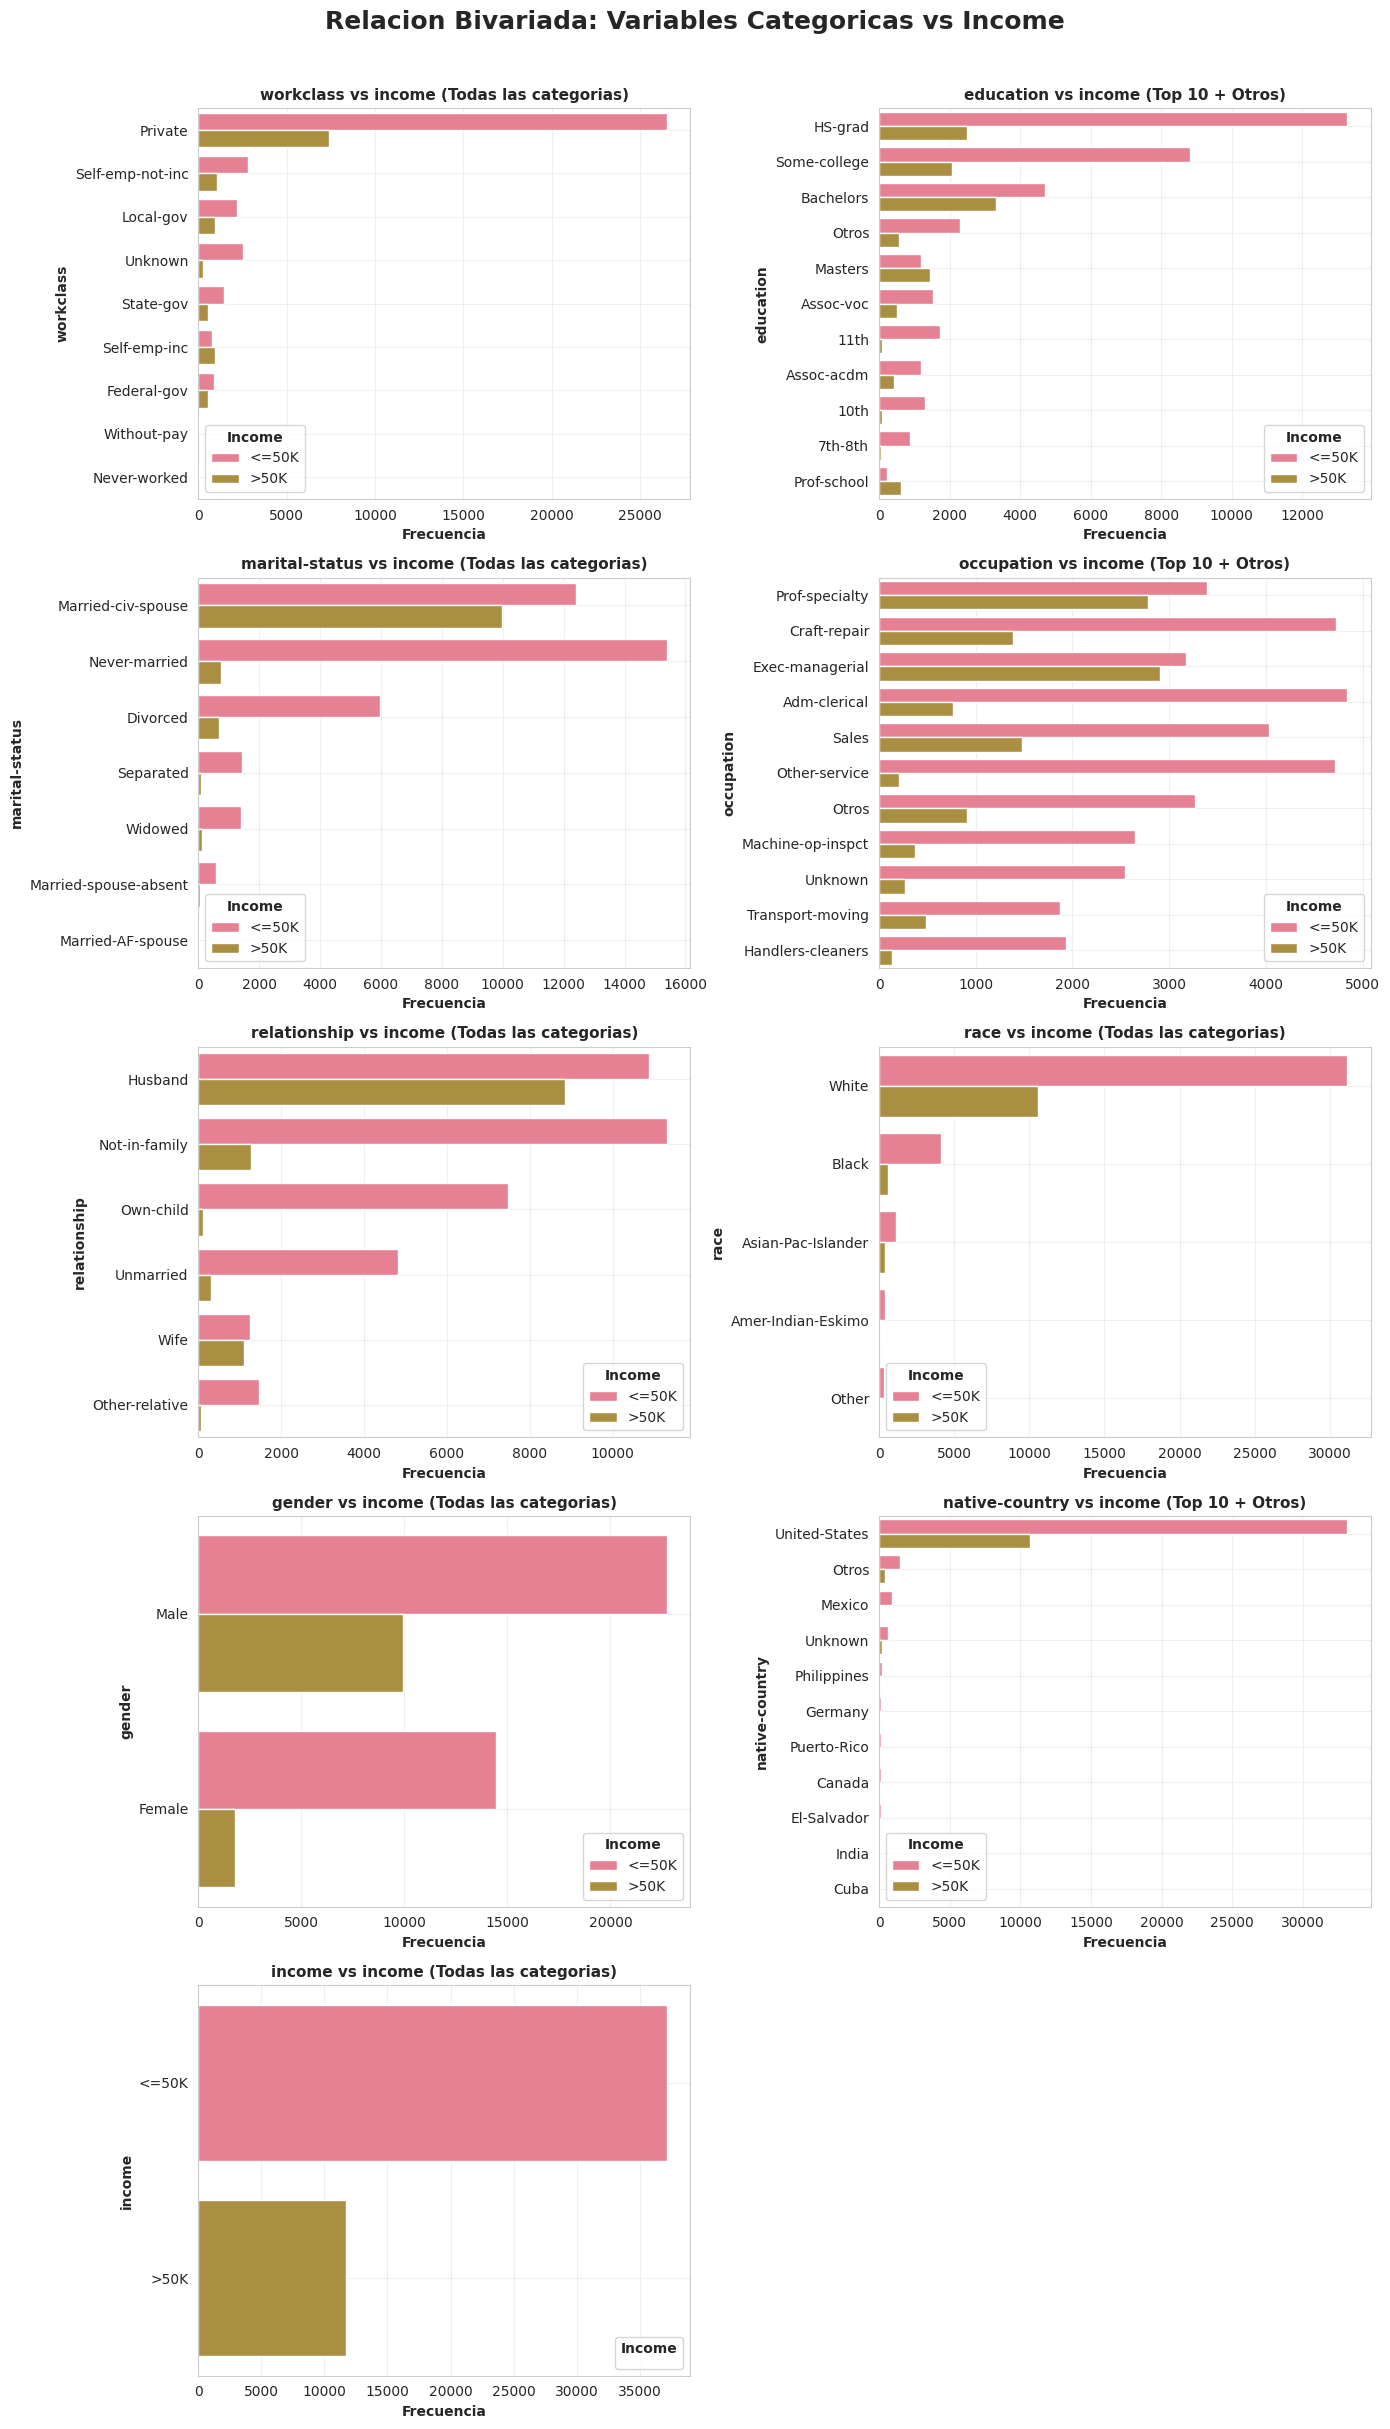

In [24]:
TOP_N = 10
fig, axes = subplot_grid(len(cat_cols), n_cols=2, width=7, height=4.8)

for ax, column in zip(axes, cat_cols):
    plot_series, order, grouped = prepare_top_categories(df[column], top_n=TOP_N)
    plot_df = df.assign(**{column: plot_series})

    sns.countplot(
        data=plot_df,
        y=column,
        hue=TARGET_COLUMN,
        order=order,
        ax=ax,
    )

    suffix = f"Top {TOP_N} + Otros" if grouped else "Todas las categorias"
    style_ax(
        ax,
        title=f"{column} vs income ({suffix})",
        xlabel="Frecuencia",
        ylabel=column,
    )
    ax.legend(title="Income", title_fontproperties={"weight": "bold"})

hide_unused_axes(axes, len(cat_cols))
fig.suptitle("Relacion Bivariada: Variables Categoricas vs Income", fontweight="bold", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlaciones y Heatmaps
Convertir `income` a una variable binaria, calcular correlaciones entre variables numericas y visualizar la matriz para detectar asociaciones lineales.

In [25]:
# Crear variable binaria de income solo para correlación
df['income_binary'] = (df['income'] == '>50K').astype(int)

# Matriz de correlación con variables numéricas + income_binary
corr_cols = num_cols + ['income_binary']
corr_matrix = df[corr_cols].corr()

print("\n=== MATRIZ DE CORRELACIÓN ===")
print(corr_matrix.round(3))


=== MATRIZ DE CORRELACIÓN ===
                   age  fnlwgt  educational-num  capital-gain  capital-loss  \
age              1.000  -0.077            0.031         0.077         0.057   
fnlwgt          -0.077   1.000           -0.039        -0.004        -0.004   
educational-num  0.031  -0.039            1.000         0.125         0.081   
capital-gain     0.077  -0.004            0.125         1.000        -0.031   
capital-loss     0.057  -0.004            0.081        -0.031         1.000   
hours-per-week   0.072  -0.014            0.144         0.082         0.054   
income_binary    0.230  -0.006            0.333         0.223         0.148   

                 hours-per-week  income_binary  
age                       0.072          0.230  
fnlwgt                   -0.014         -0.006  
educational-num           0.144          0.333  
capital-gain              0.082          0.223  
capital-loss              0.054          0.148  
hours-per-week            1.000          0

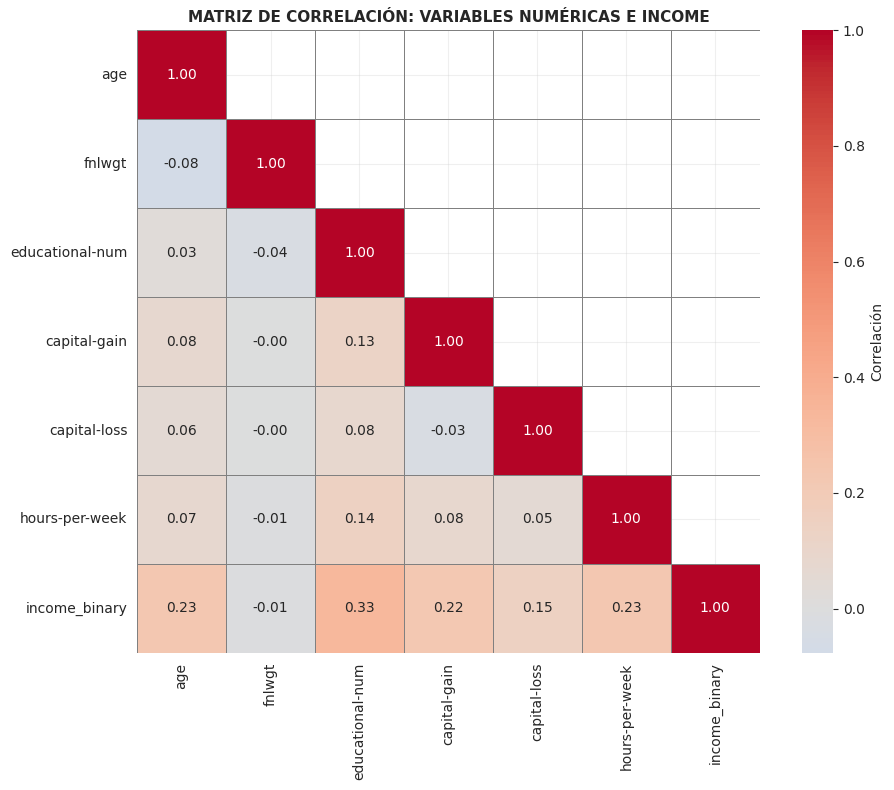

In [26]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap de correlación mostrando únicamente la parte inferior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask= mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlación'}, ax=ax, square=True,
            linewidths=0.5, linecolor='gray')
style_ax(ax, title='MATRIZ DE CORRELACIÓN: VARIABLES NUMÉRICAS E INCOME')
plt.tight_layout()
plt.show()

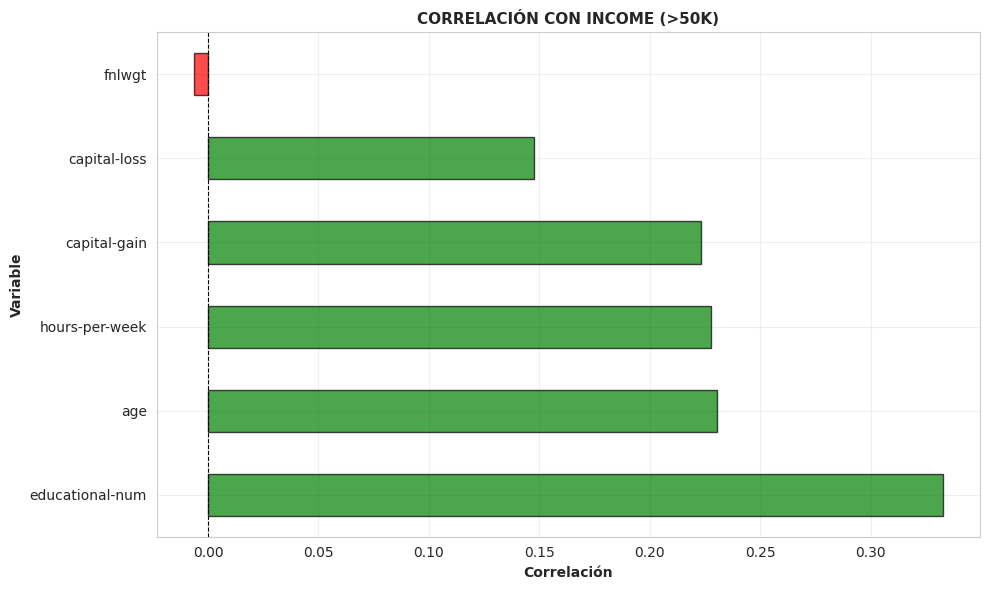

In [27]:
# Correlación de variables numéricas con income (ordenada)
income_corr = corr_matrix['income_binary'].drop('income_binary').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in income_corr.values]
income_corr.plot(kind='barh', ax=ax, color=colors, alpha=0.7, edgecolor='black')
style_ax(ax, title='CORRELACIÓN CON INCOME (>50K)', xlabel='Correlación', ylabel='Variable')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


## 7. Hallazgos y Conclusiones

### **7.1 Hallazgos Claves**

#### 1. **Balance de Clases**
- Solo ~24% de la población gana más de $50K (desequilibrio 3.8:1 a favor de ≤50K)


#### 2. **Influencia de la Educación**
- Fuerte asociación entre nivel educativo y ingreso
- Doctorado y Master: ~45-50% ganan >50K
- HS-grad y algunos college: ~10-15% ganan >50K
- La educación es uno de las variables predictoras más fuertes

#### 3. **Estado Civil**
- "Married-civ-spouse" tiene la tasa más alta de ingresos >50K (~45%)
- "Never-married" y "Divorced": <10% ganan >50K
- Relación causal vs. confundida (edad, estabilidad laboral) requiere investigación

#### 4. **Género y Disparidad Salarial**
- Hombres: ~30% ganan >50K
- Mujeres: ~11% ganan >50K
- Brecha de 19 puntos porcentuales (disparidad significativa)

#### 5. **Ocupación**
- Exec-managerial y Prof-specialty: >40% ganan >50K
- Craft-repair, Sales, Tech-support: 20-30% ganan >50K
- Farming-fishing, Handlers-cleaners: <5% ganan >50K
- Ocupación es predictor fuerte pero puede estar correlacionada con educación

#### 6. **Horas de Trabajo**
- Fuerte correlación positiva con ingreso (+0.33)
- Personas que trabajan >60 hrs/semana: ~45% ganan >50K
- Personas que trabajan <20 hrs/semana: ~5% ganan >50K
- Pero: causalidad poco clara (¿más horas→más ingreso? ¿o mejor salario→permiso de más horas?)

#### 7. **Edad**
- Relación no lineal: aumenta hasta ~50-55 años, luego decrece
- Peak: rango 40-50 años (~35% ganan >50K)
- Jóvenes <30: ~10% ganan >50K
- Adultos mayores >60: ~20% ganan >50K (acumulación de ingresos previos?)

#### 8. **Ganancias de Capital**
- Variable muy sesgada (mayoría = 0)
- Personas con capital-gain >0: probabilidad mucho mayor de >50K
- Puede reflejar sesgo de muestreo o sesgo de observación (datos históricos)
- Correlación: +0.22 (moderada positiva)

#### 9. **Raza/Etnicidad**
- White: ~26% ganan >50K
- Asian-Pac-Islander: ~26% ganan >50K  
- Black: ~12% ganan >50K
- Amer-Indian-Eskimo: ~6% ganan >50K
- Disparidades presentes, pero requiere análisis estratificado por educación/ocupación

#### 10. **Matriz de Correlación**
- **hours-per-week**: +0.33 (correlación más fuerte)
- **educational-num**: +0.32 (segunda correlación más fuerte)
- **age**: +0.24 (correlación positiva moderada)
- **capital-gain**: +0.22 (positiva, pero datos sesgados)
- **fnlwgt**: ~0.0 (peso del muestreo, no correlacionado)
- **capital-loss**: ~0.0 (muy pocos casos)

### **7.2 Limitaciones del Análisis**

1. **Valores faltantes representados como "?"** → Tratados como categoría propia, no se removieron. Introduce ruido en análisis categóricos (workclass, occupation, native-country)

2. **fnlwgt (peso final del muestreo)** → No interpretable como feature directa; solo para propósitos de ponderación en análisis de población. No se debe incluir en modelamiento predictivo.

3. **Relaciones de causalidad** → Este EDA identifica ASOCIACIONES, no relaciones causales; por ejemplo: más educación ↔ más ingreso, pero no esta probado si educación CAUSA ingreso o si son ambas consecuencia de estatus socioeconómico previo

4. **Sesgo de selección** → Datos solo incluyen trabajadores censados; falta desempleados, fuera del mercado laboral, economía informal

5. **Outliers extremos** → capital-gain y capital-loss tienen outliers masivos (no normal); fnlwgt también muy sesgado.

